In [ ]:
#Importe de librerias necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder
#Lectura de datos sucios del data set
data = pd.read_csv('dataset_clientes.csv')
data.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


## Analisis de tipos de datos de cada categoria (columna)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

## Descripcion analisis valores columnas cuantitativas
Identificamos que las columnas "tiene_tarjeta_credito" y "abandono" debe ser booleano y no entero, ya que sus valores o son 1 o son 0.

In [ ]:
data.drop(columns=["id_cliente","codigo_postal"]).describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,abandono
count,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,0.396814
std,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,0.489249
min,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,0.000000
50%,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,0.000000
75%,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,1.000000
max,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,1.000000


## Descripcion y analisis columnas cualitativas
columnas ordinales: "uso_app","tipo_plan"

columnas nominales: "genero","region","estado_civil","canal_registro","dia_semana_registro"

In [ ]:
data.describe(include="object")

,fecha_registro,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro
count,20400,20400,20400,20400,20400,20400,20400,20400
unique,2000,3,3,3,3,3,3,7
top,2022-04-09,Otro,Sur,Casado,Bajo,Estandar,App,Miercoles
freq,21,6997,6812,6828,6886,6878,6894,3000


In [ ]:
data.region.unique()

array(['Norte', 'Centro', 'Sur'], dtype=object)

In [ ]:
data.estado_civil.unique()


array(['Divorciado', 'Soltero', 'Casado'], dtype=object)

In [ ]:
data.tipo_plan.unique()

array(['Estandar', 'Premium', 'Basico'], dtype=object)

In [ ]:
data.uso_app.unique()

array(['Bajo', 'Medio', 'Alto'], dtype=object)

In [ ]:
data.canal_registro.unique()

array(['Tienda', 'App', 'Web'], dtype=object)

In [ ]:
data.genero.unique()

array(['Otro', 'Masculino', 'Femenino'], dtype=object)

##Analisis de nulos
Determinamos que "ingreso_mensual" ,"gasto_mensual"y"score_crediticio" contienen la misma cantidad de nulos.

In [ ]:
data.isnull().sum()
#Obtencion de datos nulos

,0
id_cliente,0
fecha_registro,0
edad,0
genero,0
region,0
estado_civil,0
ingreso_mensual,1021
gasto_mensual,1025
deuda_total,0
score_crediticio,1021


##Analisis de duplicados


In [ ]:
data.duplicated().sum()
#Obtencion de duplicados
data[data.duplicated(keep=False)].sort_values(by='id_cliente')

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
20032,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
177,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
215,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
20300,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
20348,327,2019-07-15,43,Femenino,Sur,Soltero,611018.691110,238932.156632,8.764364e+05,618.183493,...,303,Medio,Basico,3,0,App,Lunes,11,6291,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19921,19922,2020-01-22,52,Masculino,Sur,Casado,892522.042338,161697.180367,1.750559e+06,662.274443,...,274,Bajo,Premium,1,0,App,Viernes,3,4398,1
19923,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,145,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1
20289,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,145,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1
20147,19983,2022-02-17,26,Otro,Centro,Soltero,947809.404071,221838.916723,3.226056e+06,556.285263,...,361,Alto,Basico,1,1,Tienda,Jueves,5,6118,1


##Analisis de atipicos
Definimos que "tiene_tarjeta_credito"y"abandono" no son candidatos para la busqueda de atipicos, ya que cuentan como categoricos (booleanos).
Además podemos identificar las columnas "ingreso_mensual",	"gasto_mensual",	"deuda_total",	"score_crediticio" con alta probabilidad de tener datos atipicos.


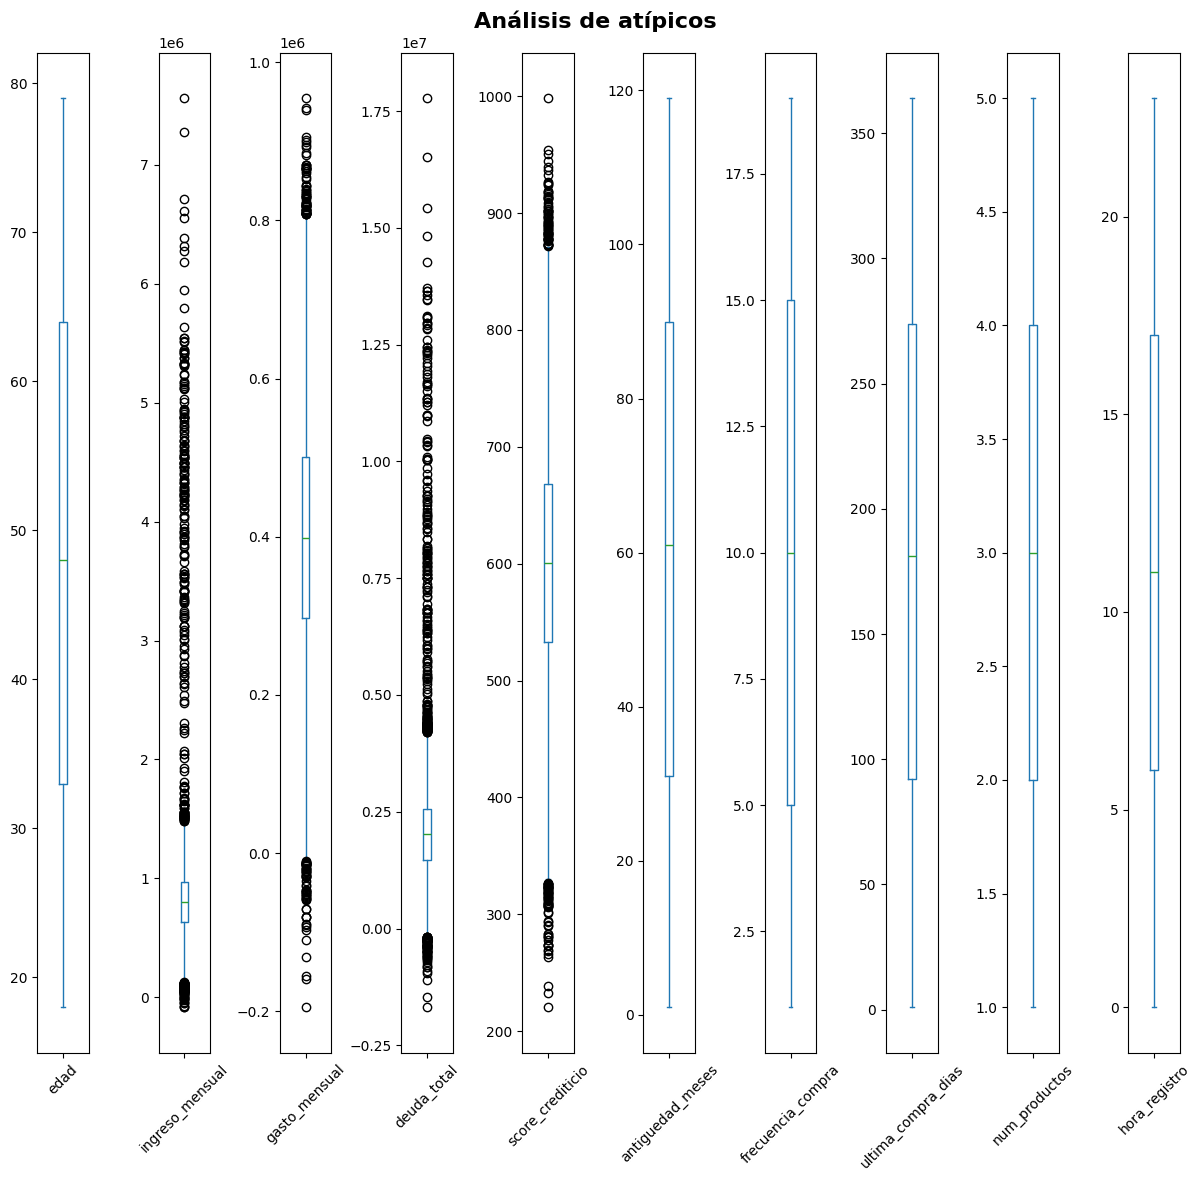

In [ ]:
registro_atipicos=["edad",	"ingreso_mensual",	"gasto_mensual",	"deuda_total",	"score_crediticio",	"antiguedad_meses",	"frecuencia_compra",	"ultima_compra_dias",	"num_productos",	"hora_registro"]
fig, axes = plt.subplots(1, 10, figsize=(20,20))
axes = axes.flatten()
for i, col in enumerate(registro_atipicos):
  data[col].plot(kind='box',figsize=(12,12), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

##Graficación de columnas numericas

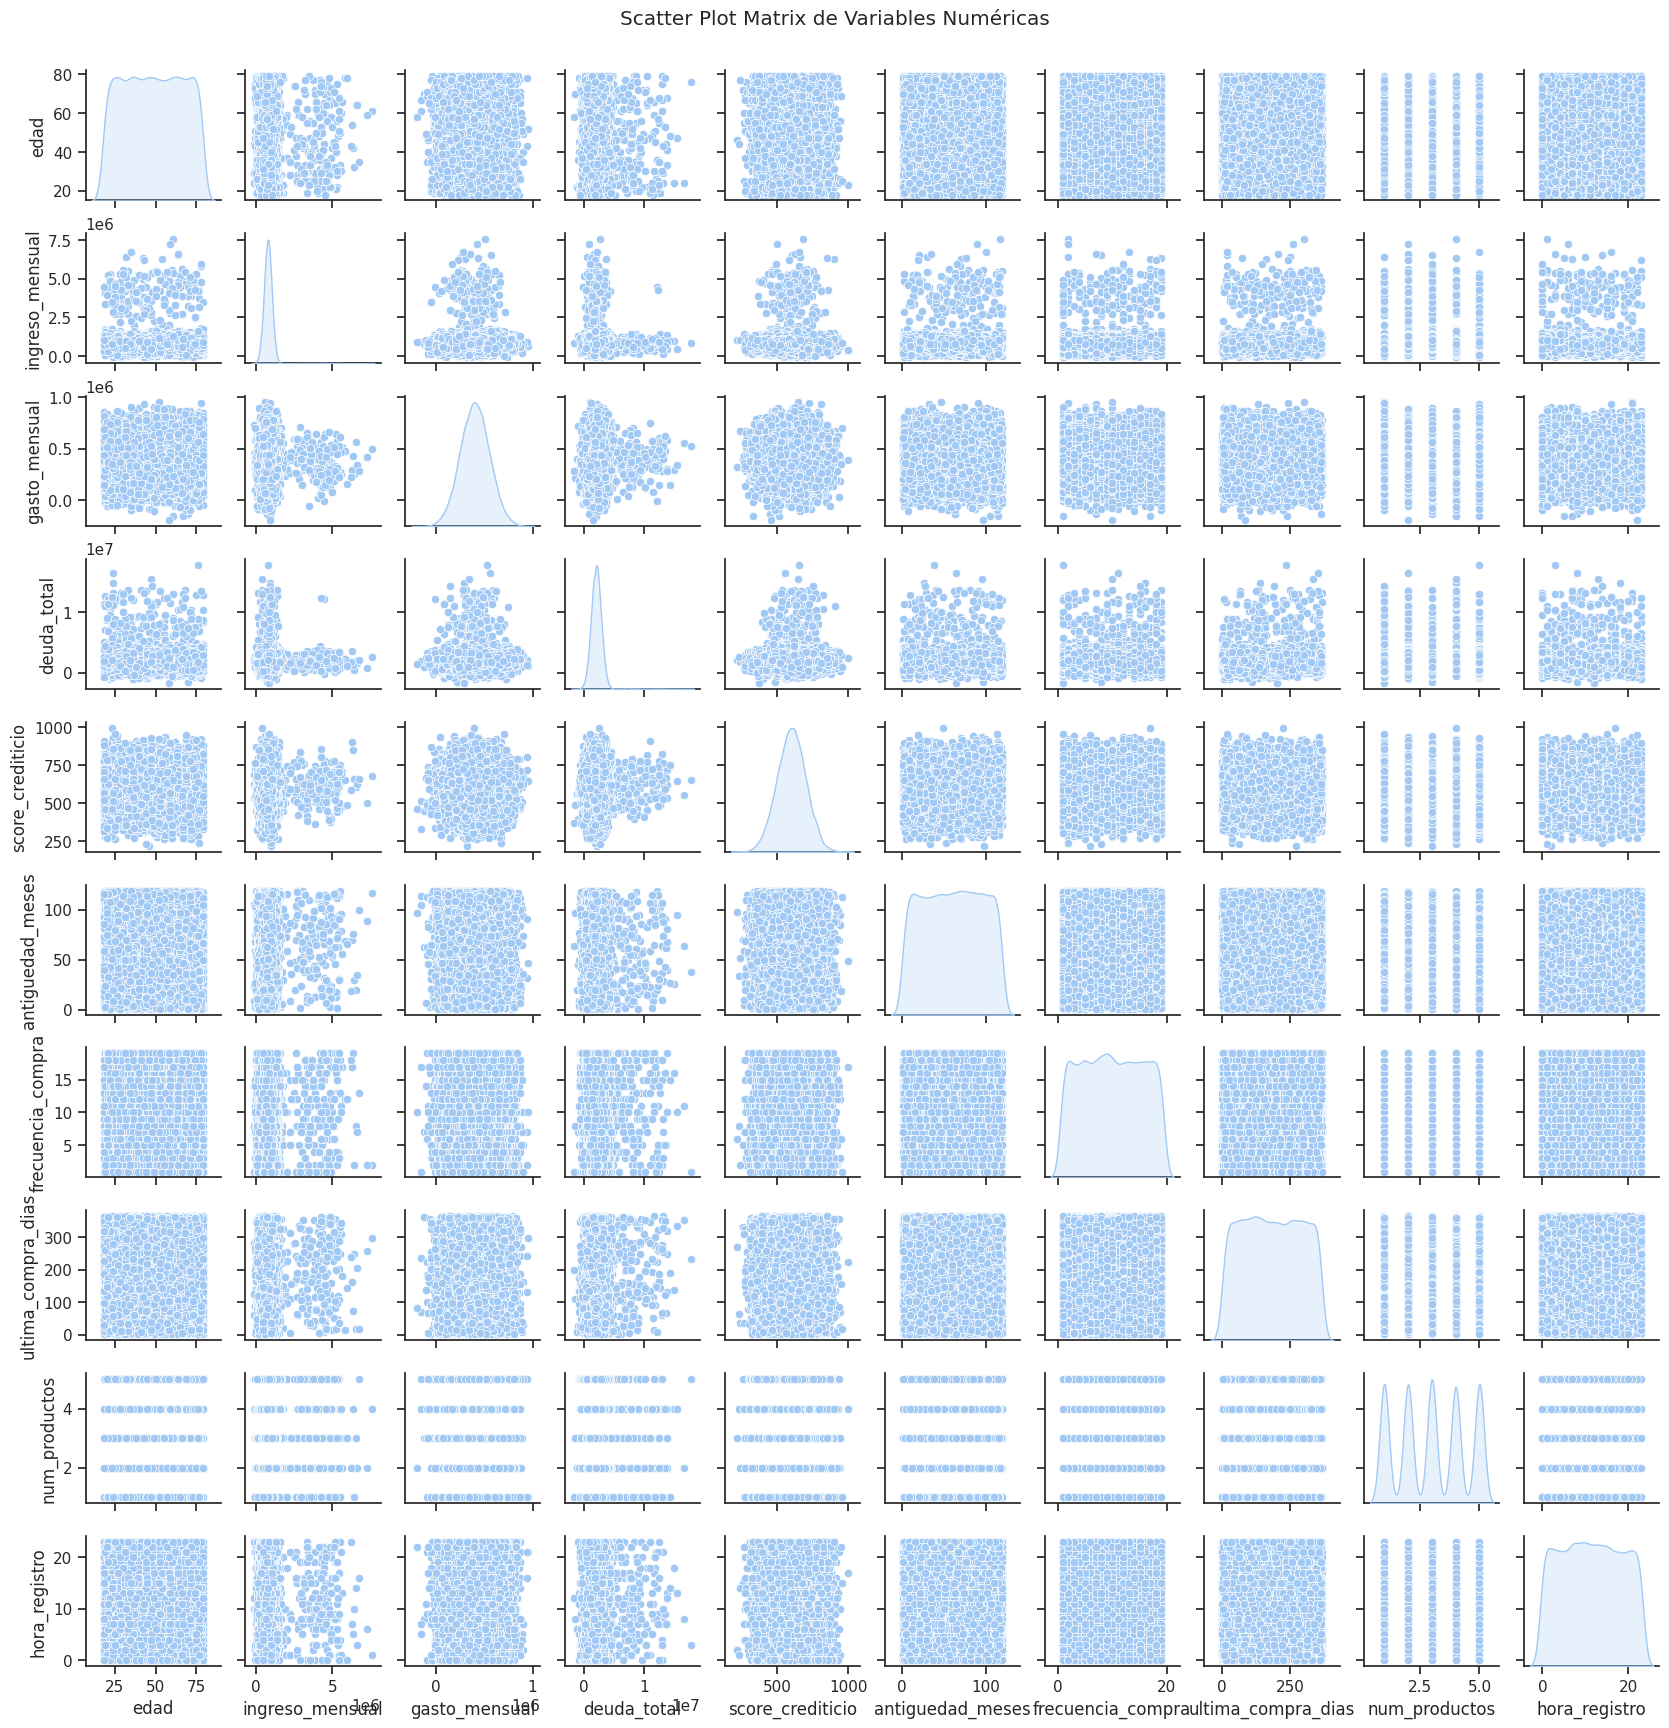

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ["edad",	"ingreso_mensual",	"gasto_mensual",	"deuda_total",	"score_crediticio",	"antiguedad_meses",	"frecuencia_compra",	"ultima_compra_dias",	"num_productos",	"hora_registro"]

# Scatter plot matrix más compacto
sns.set(style="ticks", palette="pastel")
pairplot = sns.pairplot(
    data[numeric_cols],
    kind='scatter',
    diag_kind='kde',
    height=1.7
)
pairplot.fig.suptitle("Scatter Plot Matrix de Variables Numéricas", y=1.02)
plt.show()

##Clase para winsorizar los datos
Esto con el fin de limpiar los outliers.

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        # Calculamos y guardamos los límites matemáticos AQUÍ (Fase de aprendizaje)
        self.lower_bounds_ = X_df.quantile(self.limits[0])
        self.upper_bounds_ = X_df.quantile(1 - self.limits[1])
        self.columns_ = X_df.columns if isinstance(X, pd.DataFrame) else np.arange(X.shape[1])
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns_).copy()
        X_df = X_df.astype("float64")
        # Aplicamos los límites guardados
        for col in self.columns_:
            X_df[col] = np.clip(X_df[col], self.lower_bounds_[col], self.upper_bounds_[col])
        return X_df

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns_)
        else:
            return np.array(input_features)

##Tratamiento de duplicados

In [ ]:
def eliminar_duplicados(X):
  return X.drop_duplicates()

##Construccion de arrays para procesamiento

In [ ]:
num_sesgados_derecha_outliers = ["ingreso_mensual", "deuda_total"]
num_campana_outliers = ["gasto_mensual", "score_crediticio"]
numerical_features = ["edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"]
categorical_nominales = ["genero", "region", "estado_civil", "canal_registro","dia_semana_registro"]
categorical_ordinales = ["tipo_plan", "uso_app"]
categorical_boolean_int_features = ["tiene_tarjeta_credito",	"abandono"]
date_time_features = ["fecha_registro"]
orden_tipo_plan = ['Basico', 'Estandar', 'Premium']
orden_uso_app = ['Bajo', 'Medio', 'Alto']

##Pipelines para cada tipo de conjunto


In [ ]:
pipeline_sesgados_outliers = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('winsorizer', Winsorizer(limits=(0.0, 0.05))),
    ('scaler', StandardScaler())
])

In [ ]:
pipeline_campana_outliers = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('winsorizer', Winsorizer(limits=(0.02, 0.02))),
    ('scaler', StandardScaler())
])

In [ ]:
pipeline_numerical_features = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
pipeline_nominales = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
pipeline_ordinales = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[orden_tipo_plan, orden_uso_app]))
])

In [ ]:
pipeline_booleans = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

##Integracion de pipelines de transformacion


In [ ]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num_sesgo', pipeline_sesgados_outliers, num_sesgados_derecha_outliers),
        ('num_campana', pipeline_campana_outliers, num_campana_outliers),
        ('num_limpios', pipeline_numerical_features, numerical_features),
        ('cat_nom', pipeline_nominales, categorical_nominales),
        ('cat_ord', pipeline_ordinales, categorical_ordinales),
        ('bool',pipeline_booleans,categorical_boolean_int_features)
    ],
    remainder='drop'
)

##Pipeline para limpieza


In [ ]:
data.describe()

,id_cliente,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,codigo_postal,abandono
count,20400.000000,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,10004.989853,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,5488.970147,0.396814
std,5767.007342,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,2602.374998,0.489249
min,1.000000,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1000.000000,0.000000
25%,5016.750000,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,3239.000000,0.000000
50%,10014.500000,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,5477.500000,0.000000
75%,14984.250000,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,7775.000000,1.000000
max,20000.000000,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,9998.000000,1.000000


In [ ]:
pipeline_limpieza = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(eliminar_duplicados)),
        ("preprocesamiento", preprocesador)
    ]
)

In [ ]:
data_transformada = pd.DataFrame(
    pipeline_limpieza.fit_transform(data),
    columns=pipeline_limpieza.named_steps["preprocesamiento"].get_feature_names_out()
)
data_transformada.columns = data_transformada.columns.str.replace("num_sesgo__", "")
data_transformada.columns = data_transformada.columns.str.replace("num_campana__", "")
data_transformada.columns = data_transformada.columns.str.replace("num_limpios__", "")
data_transformada.columns = data_transformada.columns.str.replace("cat_nom__", "")
data_transformada.columns = data_transformada.columns.str.replace("cat_ord__", "")
data_transformada.columns = data_transformada.columns.str.replace("bool__", "")
data_transformada.head()

,ingreso_mensual,deuda_total,gasto_mensual,score_crediticio,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,...,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,tiene_tarjeta_credito,abandono
0,0.529496,0.567805,0.879141,-1.539597,0.979150,1.193186,-0.724598,1.653219,0.002765,1.535116,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
1,1.794295,-0.484317,-0.601263,-0.269719,0.139166,0.140295,-0.358339,1.186639,0.711810,-0.205888,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0
2,0.020032,1.782807,-0.086701,1.807105,-0.028831,-1.731512,0.374180,0.472486,0.711810,-0.786223,...,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,0.0
3,-1.540667,1.268568,0.125919,-1.674225,0.307163,-1.643771,-1.273987,-0.165490,-0.706279,0.664614,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0
4,-0.249677,-0.462523,0.645420,-1.403932,-0.980813,-1.351302,-0.907728,0.958110,0.002765,-0.496056,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0


In [ ]:
data_transformada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ingreso_mensual                20000 non-null  float64
 1   deuda_total                    20000 non-null  float64
 2   gasto_mensual                  20000 non-null  float64
 3   score_crediticio               20000 non-null  float64
 4   edad                           20000 non-null  float64
 5   antiguedad_meses               20000 non-null  float64
 6   frecuencia_compra              20000 non-null  float64
 7   ultima_compra_dias             20000 non-null  float64
 8   num_productos                  20000 non-null  float64
 9   hora_registro                  20000 non-null  float64
 10  genero_Femenino                20000 non-null  float64
 11  genero_Masculino               20000 non-null  float64
 12  genero_Otro                    20000 non-null 

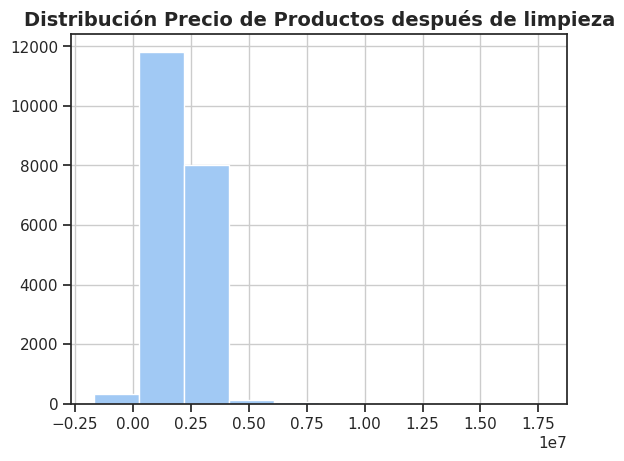

In [ ]:
data['deuda_total'].hist()
plt.title('Distribución Precio de Productos después de limpieza', fontsize=14, fontweight="bold")
plt.show()

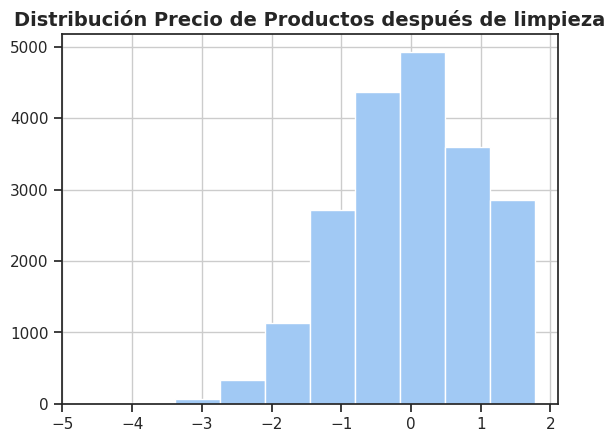

In [ ]:
data_transformada['deuda_total'].hist()
plt.title('Distribución Precio de Productos después de limpieza', fontsize=14, fontweight="bold")
plt.show()